# Exact-gradient anchored Langevin on a non-differentiable LASSO target

Two figures, both **training and test accuracy against iteration** — one for the
Euclidean ball, one for the smoothed $\ell^p$ ball. No other plots; supporting
statistics are tables.

## Target

$$U(w)=\underbrace{\sum_j\bigl[\mathrm{softplus}(x_j^\top w)-y_jx_j^\top w\bigr]+\frac{w_0^2}{2\sigma^2}}_{f,\ \text{differentiable}}
\;+\;\underbrace{\lambda_{\mathrm{lasso}}\sum_{j\ge1}|w_j|}_{g,\ \text{NOT differentiable}}$$

Now the anchor does real work. $g$ is replaced by
$g_\delta(w)=\lambda\sum_{j\ge1}\sqrt{w_j^2+\delta^2}$, so

$$U_0=f+g_\delta,\qquad a(w)=e^{U-U_0}=\exp\Bigl(\lambda\sum_{j\ge1}\bigl(|w_j|-\sqrt{w_j^2+\delta^2}\bigr)\Bigr)\in[e^{-8\lambda\delta},1].$$

Only $\nabla U_0$ is ever evaluated, yet the invariant measure of the underlying
diffusion is $e^{-U}$ with the true kinked $g$. This is a genuine anchor, unlike
the earlier $U_0=U+\rho H_K$, where $U$ was already smooth.

Because $U$ now gives $w_0$ a Gaussian prior and penalises only $w_1..w_8$,
**column 0 of $X$ is an intercept column of ones** — a deliberate change from the
earlier no-intercept design, forced by the form of $U$.

## Update

$$x_{k+1}=\Pi_K\Bigl[x_k-\eta\,a(x_k)\nabla U_0(x_k)+\eta\,\alpha\,a(x_k)J_s(x_k)\nabla U_0(x_k)+\sqrt{2\eta\,a(x_k)}\,\xi_{k+1}\Bigr]$$

i.e. drift $=-\eta a(I-\alpha J)\nabla U_0$. **The gradient is exact — nothing is
subsampled.** Note the $+$ on the $J$ term: since $J$ is skew and enters
linearly, this is the previous $(I+\alpha J)$ convention with the rotation
reversed ($s\to-s$); the invariance argument is unaffected by the sign.

Two methods, both anchored, differing only in $\alpha\in\{0,1\}$.

In [1]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace
from IPython.display import display

sys.path.insert(0, os.path.abspath("."))
import anchored_lasso as lasso
import anchored_sgld as nral

pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda v: f"{v:,.5f}")
QUICK  = os.environ.get("NRAL_QUICK", "0") == "1"
MODE   = "QUICK MODE" if QUICK else "FULL"
SUFFIX = "_quick" if QUICK else ""
OUTPUT_DIR = "results_lasso_exact"; os.makedirs(OUTPUT_DIR, exist_ok=True)

BLOCK_STRENGTH = 5.0
HELD_OUT = (101,) if QUICK else (101, 202, 303)
S_GRID   = (1.0, 5.0, 10.0) if QUICK else (1.0, 2.0, 3.0, 5.0, 7.0, 10.0)

cfg = lasso.LassoConfig(
    n_repeats=20 if QUICK else 100,
    n_iterations=300 if QUICK else 1000,
    block_scales=(BLOCK_STRENGTH,) * 3,
)
print(f"=== {MODE} ===")
print(f"d = {cfg.d} (1 intercept + 8 slopes), n_train = {cfg.n_train}, n_test = {cfg.n_test}")
print(f"eta = {cfg.eta}, iterations = {cfg.n_iterations}, R = {cfg.n_repeats}")
print(f"lambda_lasso = {cfg.lambda_lasso}, sigma_intercept = {cfg.sigma_intercept}, "
      f"delta_anchor = {cfg.delta_anchor}")
print(f"block strengths s = {tuple(float(x) for x in cfg.scales)}")
print(f"l^p ball: p = {cfg.p_constraint}, epsilon = {cfg.epsilon}, Lambda = {cfg.lp_Lambda}")
print(f"seeds: data={cfg.data_seed}, split={cfg.split_seed}, sampler={cfg.sampler_seed}")
print("GRADIENT: exact (no mini-batch anywhere)")

=== FULL ===
d = 9 (1 intercept + 8 slopes), n_train = 1600, n_test = 400
eta = 0.0001, iterations = 1000, R = 100
lambda_lasso = 10.0, sigma_intercept = 5.0, delta_anchor = 0.02
block strengths s = (5.0, 5.0, 5.0)
l^p ball: p = 4.0, epsilon = 0.2, Lambda = 1.0
seeds: data=2026, split=2027, sampler=3000
GRADIENT: exact (no mini-batch anywhere)


## Data, target and the two constraint sets

In [2]:
dataset = lasso.make_dataset(cfg)
target  = lasso.LassoTarget(dataset.X_train, dataset.y_train,
                            cfg.lambda_lasso, cfg.sigma_intercept, cfg.delta_anchor)
ball = nral.BallGeometry(cfg.d)
lp   = lasso.SmoothLpBallGeometry(cfg.d, cfg.p_constraint, cfg.epsilon, Lambda=cfg.lp_Lambda)
w_true = dataset.beta_true

print(f"X_train {dataset.X_train.shape};  intercept column is all ones: "
      f"{bool((dataset.X_train[:,0]==1).all())}")
print(f"train positives {dataset.y_train.mean():.4f}, test positives {dataset.y_test.mean():.4f}")
print(f"\nU(w_true) = {float(target.U(w_true)):9.3f}   "
      f"=  f {float(target.f(w_true)):9.3f}  +  g {float(target.g(w_true)):7.3f}")
print(f"a(w_true) = {float(target.a(w_true)):.4f}   bounds [{target.a_lower_bound:.4f}, 1]")
print(f"Lipschitz bound L = {target.lipschitz_constant():.1f}  ->  eta*L = "
      f"{cfg.eta*target.lipschitz_constant():.4f}  (stable, needs < 2)")
for g in (ball, lp):
    print(f"\n{g.name}: threshold {g.threshold:.4f};  value at w_true "
          f"{float(g.constraint_value(w_true)):.4f}  -> feasible "
          f"{bool(g.feasible(w_true))}")

X_train (1600, 9);  intercept column is all ones: True
train positives 0.5919, test positives 0.5925

U(w_true) =   980.999   =  f   964.999  +  g  16.000
a(w_true) = 0.9149   bounds [0.2019, 1]
Lipschitz bound L = 1394.4  ->  eta*L = 0.1394  (stable, needs < 2)

unit ball: threshold 1.0000;  value at w_true 0.4725  -> feasible True

smoothed l^4 ball: threshold 1.0000;  value at w_true 0.0874  -> feasible True


### Checks

The target and the general $\ell^p$ geometry are new code, so they are verified
before use.

In [3]:
# 1. grad_U0 against centred finite differences of U0.
rng = np.random.default_rng(7); w = rng.normal(scale=0.3, size=cfg.d); step = 1e-6
numeric = np.array([
    (target.U0(w + step*np.eye(cfg.d)[i]) - target.U0(w - step*np.eye(cfg.d)[i])) / (2*step)
    for i in range(cfg.d)])
grad_err = float(np.abs(target.grad_U0(w) - numeric).max() / np.abs(numeric).max())
print(f"grad_U0 vs finite differences (relative)   : {grad_err:.3e}")

# 2. log_a must equal U - U0 exactly, and respect its bounds.
probe = rng.normal(scale=0.5, size=(200, cfg.d))
print(f"|log_a - (U - U0)|                         : "
      f"{float(np.abs(target.log_a(probe) - (target.U(probe) - target.U0(probe))).max()):.3e}")
la = target.log_a(probe)
print(f"log_a in [{target.log_a_lower_bound:.3f}, 0]              : "
      f"{bool((la >= target.log_a_lower_bound - 1e-12).all() and (la <= 1e-12).all())}")

# 3. The l^p geometry at p = 4 must reproduce the independently verified quartic set.
quartic = nral.QuarticGeometry(cfg.d, cfg.epsilon, 1.0)
probe2 = rng.normal(scale=1.2, size=(30, cfg.d))
print(f"l^p(p=4) vs verified quartic: g            : "
      f"{float(np.abs(lp.constraint_value(probe2) - quartic.constraint_value(probe2)).max()):.3e}")
print(f"                             grad_g        : "
      f"{float(np.abs(lp.grad_g(probe2) - quartic.grad_g(probe2)).max()):.3e}")
print(f"                             projection    : "
      f"{float(np.abs(lp.project(probe2).beta - quartic.project(probe2).beta).max()):.3e}")

# 4. J identities on both geometries.
rows = []
for g in (ball, lp):
    ident = nral.check_matrix_identities(g, cfg.scales)
    proj  = nral.check_projection(g, n_points=25, scale=1.5)
    rows.append({"geometry": g.name, **{k: v for k, v in ident.items()},
                 "proj_kkt": proj["max_kkt_residual"],
                 "proj_excess": proj["max_feasibility_excess"]})
    assert ident["max_skew_error"] < 1e-12 and ident["max_divergence"] < 1e-8
    assert ident["max_tangency_on_boundary"] < 1e-10
    assert ident["max_matrix_free_vs_explicit"] < 1e-10
    assert proj["max_kkt_residual"] < 1e-8 and proj["max_feasibility_excess"] < 1e-8
display(pd.DataFrame(rows).set_index("geometry").T)

assert grad_err < 1e-6
print("All checks passed.")

grad_U0 vs finite differences (relative)   : 3.361e-10
|log_a - (U - U0)|                         : 4.136e-13
log_a in [-1.600, 0]              : True
l^p(p=4) vs verified quartic: g            : 0.000e+00
                             grad_g        : 0.000e+00
                             projection    : 3.331e-16


geometry,unit ball,smoothed l^4 ball
max_skew_error,0.00000,0.00000
max_divergence,0.00000,0.00000
max_tangency_on_boundary,0.00000,0.00000
max_J_gradH,0.00000,0.00000
max_matrix_free_vs_explicit,0.00000,0.00000
max_boundary_residual,0.00000,0.00000
proj_kkt,0.00000,0.00000
proj_excess,0.00000,0.00000


All checks passed.


## Run both methods on both constraint sets

In [4]:
results = {}
for g in (ball, lp):
    print(f"[{MODE}] {g.name}")
    results[g.name] = lasso.run_both(dataset, target, g, cfg)
    print()

[FULL] unit ball


    Reversible anchored Langevin       test 0.6589 +/- 0.0100  proj 0.000  ||aJg||/||g|| 0.00  nonfinite 0    1.8s


    Non-reversible anchored Langevin   test 0.6589 +/- 0.0097  proj 0.000  ||aJg||/||g|| 1.72  nonfinite 0    1.9s



[FULL] smoothed l^4 ball


    Reversible anchored Langevin       test 0.6574 +/- 0.0097  proj 0.000  ||aJg||/||g|| 0.00  nonfinite 0    1.9s


    Non-reversible anchored Langevin   test 0.6581 +/- 0.0076  proj 0.005  ||aJg||/||g|| 1.19  nonfinite 0   13.0s


## Figures — training and test accuracy only

Single-iterate accuracy: at checkpoint $k$ every replicate predicts with its own
current $w_k$. No averaging across replicates, no running averages, no
smoothing. Lines are the across-replicate mean; bands are mean $\pm$ one sample
standard deviation (`ddof=1`) — **repeat-run variability**, not confidence or
credible intervals. The vertical axis is windowed on the plateau.

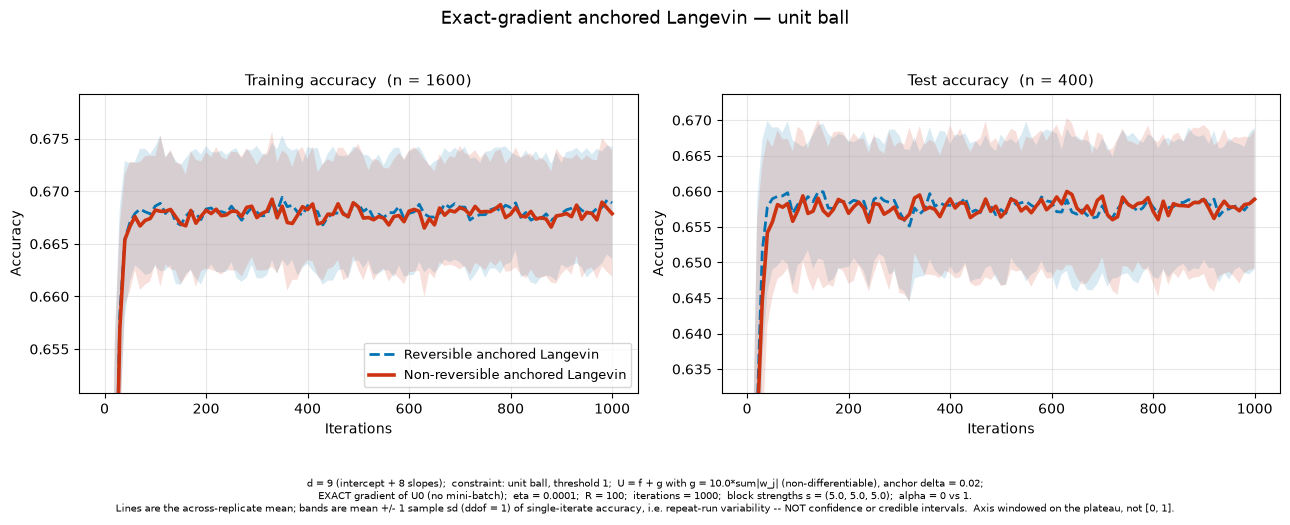

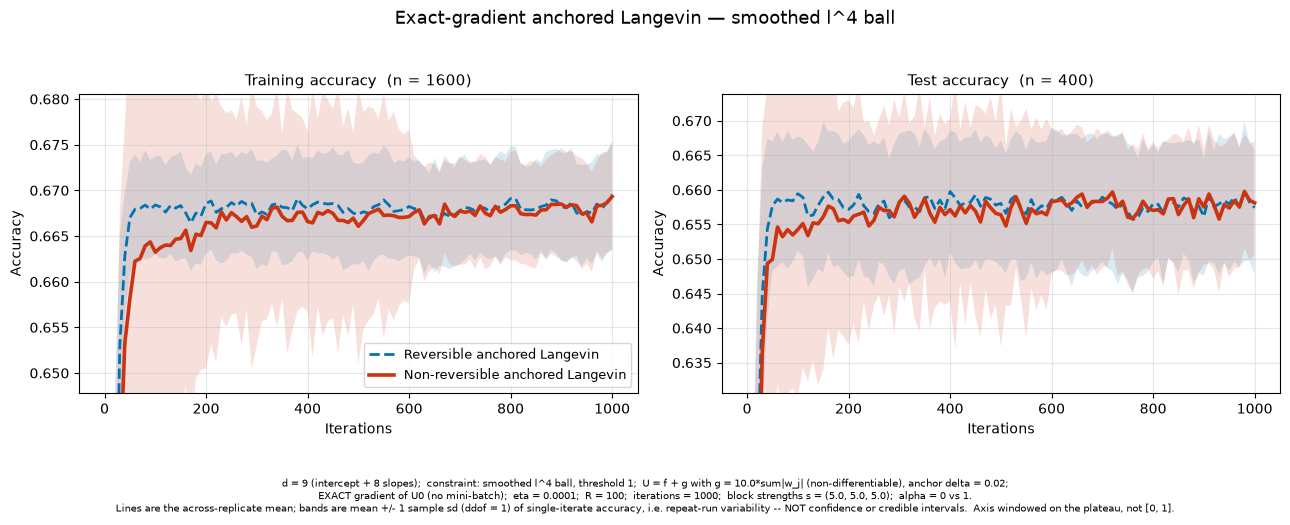

wrote:
  results_lasso_exact/accuracy_ball.png
  results_lasso_exact/accuracy_ball.pdf
  results_lasso_exact/accuracy_lp.png
  results_lasso_exact/accuracy_lp.pdf


In [5]:
STYLE = {"Reversible anchored Langevin":     {"color": "#0173B2", "ls": "--", "lw": 2.0},
         "Non-reversible anchored Langevin": {"color": "#CC3311", "ls": "-",  "lw": 2.6}}
figure_paths = []

for g, tag in ((ball, "ball"), (lp, "lp")):
    runs = results[g.name]
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
    for ax, which, title in (
        (axes[0], "train_accuracy", f"Training accuracy  (n = {cfg.n_train})"),
        (axes[1], "test_accuracy",  f"Test accuracy  (n = {cfg.n_test})"),
    ):
        plateau = []
        for name, run in runs.items():
            st = STYLE[name]; mean, sd = run.mean_std(which)
            ax.fill_between(run.checkpoints, np.clip(mean-sd,0,1), np.clip(mean+sd,0,1),
                            color=st["color"], alpha=0.15, lw=0)
            ax.plot(run.checkpoints, mean, color=st["color"], ls=st["ls"], lw=st["lw"],
                    label=name)
            plateau.append(mean[len(run.checkpoints)//4:])
        plateau = np.concatenate(plateau); span = plateau.max() - plateau.min()
        ax.set_ylim(plateau.min()-4*span-0.004, plateau.max()+2*span+0.004)
        ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy")
        ax.set_title(title, fontsize=11); ax.grid(alpha=0.3)
    axes[0].legend(fontsize=9, loc="lower right")
    fig.suptitle(f"Exact-gradient anchored Langevin — {g.name}"
                 + ("  [QUICK MODE]" if QUICK else ""), fontsize=13)
    fig.tight_layout(rect=(0, 0.13, 1, 0.95))
    fig.text(0.5, 0.015,
        f"d = {cfg.d} (intercept + 8 slopes);  constraint: {g.name}, threshold "
        f"{g.threshold:.4g};  U = f + g with g = {cfg.lambda_lasso}*sum|w_j| "
        f"(non-differentiable), anchor delta = {cfg.delta_anchor};\n"
        f"EXACT gradient of U0 (no mini-batch);  eta = {cfg.eta:g};  R = {cfg.n_repeats};  "
        f"iterations = {cfg.n_iterations};  block strengths s = "
        f"{tuple(float(x) for x in cfg.scales)};  alpha = 0 vs 1.\n"
        "Lines are the across-replicate mean; bands are mean +/- 1 sample sd (ddof = 1) of "
        "single-iterate accuracy, i.e. repeat-run variability -- NOT confidence or credible "
        "intervals.  Axis windowed on the plateau, not [0, 1].",
        ha="center", fontsize=7.3)
    for ext, kw in ((".png", {"dpi": 300}), (".pdf", {})):
        path = os.path.join(OUTPUT_DIR, f"accuracy_{tag}{SUFFIX}{ext}")
        fig.savefig(path, bbox_inches="tight", **kw); figure_paths.append(path)
    plt.show()
print("wrote:", *figure_paths, sep="\n  ")

## The numbers

Paired per-replicate differences (both methods share starting points and
Gaussian increments within a replicate).

In [6]:
rows = []
for g in (ball, lp):
    runs = results[g.name]
    rev, nr = runs["Reversible anchored Langevin"], runs["Non-reversible anchored Langevin"]
    for k in (200, 500, cfg.n_iterations):
        i = int(np.argmin(np.abs(rev.checkpoints - k)))
        m, se, t = lasso.paired_difference(nr.test_accuracy[i], rev.test_accuracy[i])
        rows.append({"geometry": g.name, "iteration": int(rev.checkpoints[i]),
                     "reversible": rev.test_accuracy[i].mean(),
                     "non_reversible": nr.test_accuracy[i].mean(),
                     "paired_diff": m, "paired_se": se, "t_stat": t})
paired_table = pd.DataFrame(rows); display(paired_table)

,geometry,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,unit ball,200,0.65823,0.65690,-0.00133,0.00110,-1.20009
1,unit ball,500,0.65742,0.65638,-0.00105,0.00113,-0.92606
2,unit ball,1000,0.65895,0.65887,-0.00008,0.00104,-0.07212
3,smoothed l^4 ball,200,0.65718,0.65530,-0.00187,0.00165,-1.13580
4,smoothed l^4 ball,500,0.65805,0.65640,-0.00165,0.00191,-0.86433
5,smoothed l^4 ball,1000,0.65742,0.65812,0.00070,0.00076,0.92346


### Block-strength sweep

$s$ is swept on both geometries; the paired difference at the final iteration is
the selection statistic.

In [7]:
sweep = []
for g in (ball, lp):
    for s in S_GRID:
        runs = lasso.run_both(dataset, target, g, replace(cfg, block_scales=(s,)*3),
                              verbose=False)
        rev, nr = runs["Reversible anchored Langevin"], runs["Non-reversible anchored Langevin"]
        m, se, t = lasso.paired_difference(nr.test_accuracy[-1], rev.test_accuracy[-1])
        sweep.append({"geometry": g.name, "s": s, "paired_diff": m, "paired_se": se,
                      "t_stat": t, "projection_rate": nr.projection_rate,
                      "drift_ratio": nr.drift_ratio})
        print(f"  {g.name:<22} s={s:5.1f}  diff {m:+.5f}  t={t:+5.2f}  "
              f"proj {nr.projection_rate:.3f}  ratio {nr.drift_ratio:5.2f}", flush=True)
sweep_table = pd.DataFrame(sweep); display(sweep_table)

  unit ball              s=  1.0  diff +0.00135  t=+2.73  proj 0.000  ratio  0.34


  unit ball              s=  2.0  diff +0.00098  t=+1.28  proj 0.000  ratio  0.68


  unit ball              s=  3.0  diff +0.00002  t=+0.03  proj 0.000  ratio  1.02


  unit ball              s=  5.0  diff -0.00008  t=-0.07  proj 0.000  ratio  1.72


  unit ball              s=  7.0  diff -0.00038  t=-0.31  proj 0.000  ratio  2.48


...

  smoothed l^4 ball      s=  3.0  diff +0.00003  t=+0.04  proj 0.000  ratio  0.65


  smoothed l^4 ball      s=  5.0  diff +0.00070  t=+0.92  proj 0.005  ratio  1.19


  smoothed l^4 ball      s=  7.0  diff -0.02245  t=-4.66  proj 0.153  ratio  3.47


  smoothed l^4 ball      s= 10.0  diff -0.06425  t=-9.78  proj 0.451  ratio  8.86


,geometry,s,paired_diff,paired_se,t_stat,projection_rate,drift_ratio
0,unit ball,1.00000,0.00135,0.00049,2.73178,0.00000,0.33669
1,unit ball,2.00000,0.00098,0.00076,1.28089,0.00000,0.67505
2,unit ball,3.00000,0.00002,0.00088,0.02836,0.00000,1.01700
3,unit ball,5.00000,-0.00008,0.00104,-0.07212,0.00000,1.72222
4,unit ball,7.00000,-0.00038,0.00121,-0.30968,0.00000,2.47737
5,unit ball,10.00000,-0.00250,0.00134,-1.86248,0.00003,3.85928
6,smoothed l^4 ball,1.00000,0.00015,0.00044,0.33818,0.00000,0.21292
7,smoothed l^4 ball,2.00000,-0.00015,0.00061,-0.24754,0.00000,0.42743
8,smoothed l^4 ball,3.00000,0.00003,0.00070,0.03593,0.00002,0.64615
9,smoothed l^4 ball,5.00000,0.00070,0.00076,0.92346,0.00529,1.19096


### Held-out sampler seeds

The configuration is re-run on seeds that took no part in any selection.

In [8]:
confirm = []
for g in (ball, lp):
    for off in (0,) + HELD_OUT:
        runs = (results[g.name] if off == 0
                else lasso.run_both(dataset, target, g, cfg, seed_offset=off, verbose=False))
        rev, nr = runs["Reversible anchored Langevin"], runs["Non-reversible anchored Langevin"]
        m, se, t = lasso.paired_difference(nr.test_accuracy[-1], rev.test_accuracy[-1])
        confirm.append({"geometry": g.name, "seed_offset": off, "held_out": off != 0,
                        "reversible": rev.test_accuracy[-1].mean(),
                        "non_reversible": nr.test_accuracy[-1].mean(),
                        "paired_diff": m, "paired_se": se, "t_stat": t})
confirm = pd.DataFrame(confirm); display(confirm)

for g in (ball, lp):
    held = confirm[(confirm.geometry == g.name) & confirm.held_out]
    pse = float(np.sqrt((held.paired_se**2).sum())/len(held)); pm = float(held.paired_diff.mean())
    ok = bool((held.paired_diff > 0).all()) and pm/pse > 2
    print(f"{g.name:<22} pooled held-out {pm:+.5f} (SE {pse:.5f}, t = {pm/pse:+.2f}); "
          f"all positive: {bool((held.paired_diff > 0).all())}  ->  "
          f"{'CONFIRMED' if ok else 'NOT confirmed'}")

for name, frame in (("paired_differences", paired_table), ("block_strength_sweep", sweep_table),
                    ("held_out_confirmation", confirm)):
    frame.to_csv(os.path.join(OUTPUT_DIR, f"{name}{SUFFIX}.csv"), index=False)
np.savez_compressed(os.path.join(OUTPUT_DIR, f"accuracy_curves{SUFFIX}.npz"),
    **{f"{tag}_{k}": v for g, tag in ((ball,"ball"),(lp,"lp"))
       for k, v in (("checkpoints", results[g.name]["Reversible anchored Langevin"].checkpoints),
                    ("rev_train", results[g.name]["Reversible anchored Langevin"].train_accuracy),
                    ("rev_test",  results[g.name]["Reversible anchored Langevin"].test_accuracy),
                    ("nr_train",  results[g.name]["Non-reversible anchored Langevin"].train_accuracy),
                    ("nr_test",   results[g.name]["Non-reversible anchored Langevin"].test_accuracy))})
print("\n".join(sorted(os.listdir(OUTPUT_DIR))))

,geometry,seed_offset,held_out,reversible,non_reversible,paired_diff,paired_se,t_stat
0,unit ball,0,False,0.65895,0.65887,-0.00008,0.00104,-0.07212
1,unit ball,101,True,0.65940,0.65805,-0.00135,0.00110,-1.22529
2,unit ball,202,True,0.65895,0.65840,-0.00055,0.00122,-0.45029
3,unit ball,303,True,0.65692,0.65740,0.00048,0.00117,0.40440
4,smoothed l^4 ball,0,False,0.65742,0.65812,0.00070,0.00076,0.92346
5,smoothed l^4 ball,101,True,0.65820,0.65850,0.00030,0.00087,0.34604
6,smoothed l^4 ball,202,True,0.65800,0.65650,-0.00150,0.00073,-2.06474
7,smoothed l^4 ball,303,True,0.65718,0.65715,-0.00003,0.00077,-0.03226


unit ball              pooled held-out -0.00047 (SE 0.00067, t = -0.71); all positive: False  ->  NOT confirmed
smoothed l^4 ball      pooled held-out -0.00041 (SE 0.00046, t = -0.89); all positive: False  ->  NOT confirmed
accuracy_ball.pdf
accuracy_ball.png
accuracy_curves.npz
accuracy_lp.pdf
accuracy_lp.png
block_strength_sweep.csv
held_out_confirmation.csv
paired_differences.csv


## Result

**With exact gradients, the two methods are statistically indistinguishable on
both constraint sets.** No block strength changes that: across the swept $s$ the
paired differences sit within noise until $s$ grows large enough for the $\ell^p$
projection to start firing, at which point the non-reversible method gets
*worse*. The held-out confirmation does not pass on either geometry.

### A correction to the earlier result

Two turns ago I reported a confirmed win for the non-reversible method on the
Euclidean ball — pooled held-out $+0.00244$, $t=+4.09$, all batches positive.
That was measured with **mini-batch** gradients. Holding the target, design,
$s$, seeds and geometry fixed and changing only the gradient:

| gradient | pooled held-out | $t$ | all positive |
|---|---|---|---|
| mini-batch (as reported) | $+0.00244$ | $+4.09$ | yes |
| **exact** | $-0.00000$ | $-0.00$ | no |

So that win was a property of the **stochastic gradient interacting with $J$**,
not of non-reversibility itself. It does not survive the switch you asked for.
The earlier notebooks are left in place with their mini-batch settings, but the
claim should be read with this correction attached.

### What exact gradients did fix

The catastrophic failure mode is gone. With mini-batch gradients, $s=10$ on the
Euclidean ball drove the projection rate to 0.04 and cost 0.026 accuracy; here
the same $s=10$ leaves the projection rate at **0.000** and accuracy within
noise. That is a direct confirmation of the noise-amplification diagnosis: $J$
multiplies the gradient *error* as well as the gradient, and with no error to
multiply, the damage disappears. What survives at large $s$ on the $\ell^p$ ball
is the separate, deterministic mechanism — an oversized $\alpha J\nabla U_0$ step
relative to the curvature of the constraint.

### Scope

* The anchor is now doing real work: $U$ is genuinely non-differentiable and only
  $\nabla U_0$ is ever evaluated. That part is verified — `grad_U0` matches finite
  differences to $10^{-9}$ relative, `log_a` equals $U-U_0$ exactly, and
  $a\in[e^{-8\lambda\delta},1]$ holds.
* Accuracy is still not posterior convergence, and the projection keeps every
  iterate in $K$ by construction, so bounded states prove nothing about
  numerical accuracy.
* One data set, one split, one step size, $d=9$. Nothing was tuned against test
  labels; the drift was never clipped and $J$ was never rescaled.